In [1]:
import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [ ]:
class State(TypedDict):
    topic: str
    plan: Plan 
    # reducer: result from workers get concatenated automatically
    sections: Annotated[List[str], operator.add] # output for worker nodes
    final: str

In [5]:
llm = ChatOpenAI()

In [39]:
def planner(state: State)-> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan with 5-7 tasks on the following topic.")
            ),
            HumanMessage(content=f"Topic {state["topic"]}")
        ]
    )
    
    return {"plan" : plan}

In [40]:
# The Send class from langgraph.types is used within a StateGraph's conditional edges to dynamically invoke a specific node with a custom state.
# It allows the graph to fan out into multiple parallel branches (Map-Reduce pattern)

# Send("node_name", {payload})
def fanout(state: State):
    return [
                Send("worker", {"task": task, "topic":state['topic'], "plan":state["plan"]}) 
                for task in state["plan"].tasks
            ]

In [41]:
def worker(payload: dict)-> dict:
    task = payload['task']
    topic = payload["topic"]
    plan = payload["plan"]
    
    # print(task.id, task.title)
    
    blog_title = plan.blog_title
    
    section_md = llm.invoke([
        SystemMessage(content="Write one clean markdown section."),
        HumanMessage(
            content=(
                f" Blog: {blog_title}\n"
                f"topic: {topic}\n"
                f"section: {task.title}"
                f"brief: {task.brief}"
                "return only section content in Markdown"
            )
        )
    ]).content.strip()
    
    return {"sections" : [section_md]}
    

In [21]:
from pathlib import Path

def reducer(state: State):
    title = state['plan'].blog_title
    body = "\n\n".join(state['sections']).strip()
    
    final_md = f"# {title} \n\n {body} \n"
    
    # --- save into the file ---
    filename = title.lower().replace(" ", "_")+".md"
    output_path = Path(filename)
    
    output_path.write_text(final_md, encoding="utf-8")
    
    return {"final": final_md}

In [42]:
g = StateGraph(State)

g.add_node("planner", planner)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge("__start__", "planner")
g.add_conditional_edges("planner", fanout, ["worker"])
g.add_edge('worker', "reducer")
g.add_edge('reducer', "__end__")

app = g.compile()

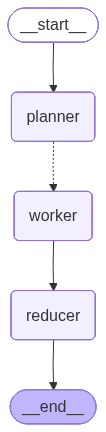

In [16]:
app

In [43]:
app.invoke({"topic":"Todays share market news"})

{'topic': 'Todays share market news',
 'plan': Plan(blog_title="Today's Share Market News", tasks=[Task(id=1, title='Summary of Market Updates', brief='Provide a brief summary of the current state of the share market, including major indices and trends.'), Task(id=2, title='Key Stock Movements', brief='Highlight the top gainers and losers in the market, along with any significant stock movements.'), Task(id=3, title='Industry Analysis', brief='Discuss the performance of different industries in the market and the factors driving their movements.'), Task(id=4, title='Impact of Economic Events', brief='Examine how recent economic events have influenced the share market and investor sentiment.'), Task(id=5, title='Expert Commentary', brief="Include insights and opinions from market experts or analysts on the day's market performance.")]),
 'sections': ['### Summary of Market Updates\n\nThe share market is currently experiencing a slight dip, with major indices like the S&P 500 and the Dow 